# Principal component analysis

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
df = pd.read_csv("modeling_tables/clustering.csv")

In [3]:
df.columns

Index(['Unnamed: 0', 'driverId', 'year', 'DNF_rate', 'ref', 'constructor',
       'constructorRef', 'position_delta', 'high_alt_sucess_rate',
       'team_avg_position', 'dvt', 'finish_volatility', 'years_active',
       'top10', 'avg_finish', 'races_entered', 'max_races_in_season',
       'season_fraction', 'total_points', 'fv_terciles', 'dvt_terciles',
       'logit_dnf', 'logit_top10'],
      dtype='str')

In [4]:
#Keep only numeric variables, prefer transformed variables, do not add total points
features = df[['position_delta', 'high_alt_sucess_rate',
       'team_avg_position', 'dvt', 'finish_volatility', 'years_active',
       'avg_finish', 'logit_dnf', 'logit_top10', "total_points"]]

In [5]:
#Scale variables
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [6]:
scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
scaled_df

,position_delta,high_alt_sucess_rate,team_avg_position,dvt,finish_volatility,years_active,avg_finish,logit_dnf,logit_top10,total_points
0,-1.269696,1.715130,-1.871234,-1.884103,0.249253,-1.086875,-1.685536,-1.055192,0.979136,2.033732
1,-0.168300,0.133435,-0.209924,0.925178,1.011360,-1.086875,-0.502174,-0.484508,0.259212,0.317942
2,0.059799,0.133435,-0.512566,1.769331,-0.957357,-1.086875,-0.999326,-1.330410,1.559517,0.632354
3,-0.537604,0.133435,-0.834525,0.671429,-0.072042,-1.086875,-0.965094,-1.330410,0.999144,0.856934
4,1.428398,-1.448260,-0.369389,0.338373,-0.449669,-1.086875,-0.453160,-0.836700,0.702396,0.048446
...,...,...,...,...,...,...,...,...,...,...
238,0.341340,-0.393796,0.828541,0.427463,-0.005640,-1.086875,0.616767,-0.209915,-0.681810,-0.795974
239,0.252707,-0.393796,-0.171718,-0.997841,0.210700,0.976489,0.188236,-0.053098,-0.224091,-0.517495
240,-2.790360,-0.657412,1.223380,-0.067371,0.217347,2.008171,1.256918,0.529737,-0.874730,-0.786990
241,-0.334487,-1.448260,0.180885,-0.445427,0.710371,1.320383,0.370759,-0.278732,-0.164745,-0.598343


In [7]:
pca = PCA()
pca_result = pca.fit_transform(scaled_features)
pca_df = pd.DataFrame(pca_result)
pca_df

,0,1,2,3,4,5,6,7,8,9
0,-3.294588,0.800184,-2.350029,-0.277565,-1.751753,-1.052161,0.712291,0.211427,-0.102881,-0.255351
1,-0.721154,-0.059846,0.167013,0.104003,-1.282462,1.201954,-0.089783,-0.343774,-0.153608,-0.062532
2,-2.157575,-1.882681,0.756466,0.413482,-1.088611,0.266672,-0.854797,-0.357677,0.234755,0.018457
3,-2.111360,-0.658992,0.087204,-0.222249,-1.334535,0.178105,-0.304907,-0.466034,-0.050209,0.009331
4,-0.572523,-1.961747,-0.212717,-1.139627,0.216350,0.949864,-0.491258,-0.679622,0.028988,-0.002318
...,...,...,...,...,...,...,...,...,...,...
238,1.405383,-0.597282,0.213710,-0.092247,-0.593282,0.396118,-0.395369,-0.874033,-0.143045,-0.096912
239,0.300339,0.721427,-0.383953,-0.544635,1.196136,-0.223683,-0.148150,-0.071717,-0.178635,0.061811
240,1.487332,2.537156,2.340866,-0.468203,0.268529,-1.562002,0.057648,0.315868,0.271909,0.085381
241,0.394231,1.117277,0.814690,-1.252195,1.219256,0.173083,-0.216852,-0.290020,0.008424,0.074978


In [8]:
#Amount of variance carried in each Principal Component.
eigenvalues = pca.explained_variance_
#Percentag of variability explained by each PC
var_explained = pca.explained_variance_ratio_
cumulative_variance = var_explained.cumsum()

variance_df = pd.DataFrame({
    'PC': ('PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10'),
    'Eigenvalue': eigenvalues,
    'Explained Variance Ratio': var_explained,
    'Cumulative Variance': cumulative_variance,
})
variance_df

,PC,Eigenvalue,Explained Variance Ratio,Cumulative Variance
0,PC1,4.727377,0.470792,0.470792
1,PC2,1.548891,0.154252,0.625044
2,PC3,1.082463,0.107801,0.732845
3,PC4,0.926382,0.092257,0.825102
4,PC5,0.723572,0.072059,0.897161
5,PC6,0.621771,0.061921,0.959082
6,PC7,0.187268,0.018650,0.977732
7,PC8,0.172938,0.017223,0.994955
8,PC9,0.038601,0.003844,0.998799
9,PC10,0.012059,0.001201,1.000000


In [9]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings, 
                           index=features.columns, 
                           columns=[f'PC{i+1}' for i in range(loadings.shape[1])])

In [10]:
loadings_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
position_delta,0.231049,-0.622887,-0.425486,0.194818,0.453090,0.364566,0.019082,-0.072018,0.004182,-0.001264
high_alt_sucess_rate,-0.250196,0.267444,-0.389638,0.814879,-0.176506,-0.148648,-0.028586,0.009642,-0.000759,0.000481
team_avg_position,0.948956,0.033314,0.235969,0.144758,-0.028762,-0.015371,-0.008944,-0.092415,0.107484,-0.068059
dvt,-0.193840,-0.377083,0.745291,0.399552,-0.149154,0.292134,-0.021989,0.009743,-0.028844,0.016322
finish_volatility,-0.032003,0.798486,-0.097021,-0.060905,-0.102191,0.582759,0.028071,-0.038749,0.007888,0.001961
years_active,-0.358176,0.511079,0.346087,0.170939,0.667169,-0.131032,0.028271,0.050543,0.002756,-0.000481
avg_finish,0.974566,0.101287,0.060132,0.053897,0.018708,-0.100266,0.042115,-0.119381,0.065777,0.082569
logit_dnf,0.922110,-0.035513,-0.058805,0.054125,-0.013102,0.087304,0.104413,0.356784,0.013885,0.003784
logit_top10,-0.949799,-0.123680,-0.046453,-0.070012,0.002955,0.080406,-0.206011,0.113615,0.132339,0.017918
total_points,-0.917500,-0.143104,0.006844,0.011672,-0.089248,-0.016445,0.358915,-0.022631,0.063997,-0.001211


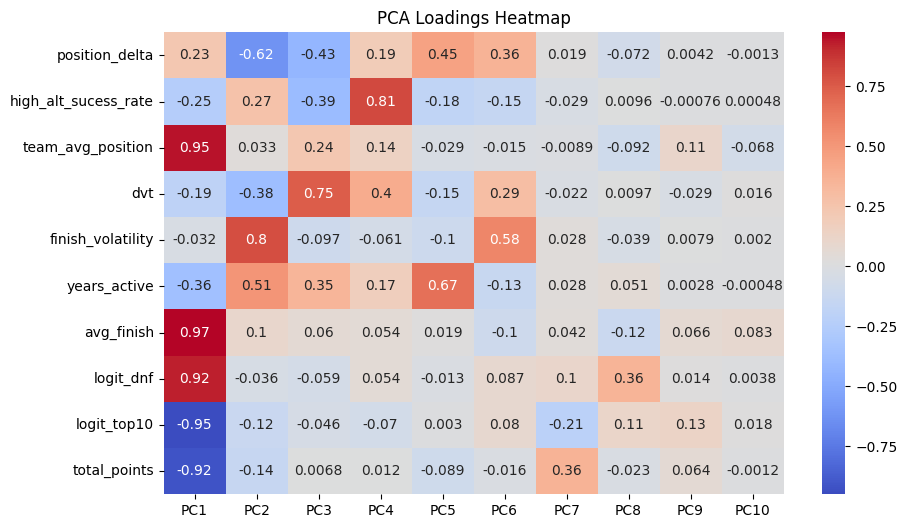

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))
sns.heatmap(loadings_df, annot=True, cmap='coolwarm')
plt.title('PCA Loadings Heatmap')
plt.savefig(f"images/analysis/pca_loadings_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

In [50]:
variance_df

,PC,Eigenvalue,Explained Variance Ratio,Cumulative Variance
0,PC1,4.727377,0.470792,0.470792
1,PC2,1.548891,0.154252,0.625044
2,PC3,1.082463,0.107801,0.732845
3,PC4,0.926382,0.092257,0.825102
4,PC5,0.723572,0.072059,0.897161
5,PC6,0.621771,0.061921,0.959082
6,PC7,0.187268,0.018650,0.977732
7,PC8,0.172938,0.017223,0.994955
8,PC9,0.038601,0.003844,0.998799
9,PC10,0.012059,0.001201,1.000000


- The first principal component (PC1) explains the largest portion of variance in the dataset, around 47%, and can be interpreted as capturing overall driver performance and consistency. Drivers with high PC1 values tend to consistently finish in the top half of the grid, reflecting strong performance across races, while low PC1 values indicate weaker or inconsistent results.
- The second principal component (PC2), accounting for approximately 15% of the variance, represents performance volatility and risk-reward dynamics. Drivers with extreme values along PC2 are either highly inconsistent or regularly outperform or underperform relative to their starting positions, making this component useful for identifying breakout or risk-prone drivers.
- PC3, explaining roughly 10% of the variance, highlights specialization in certain conditions, such as high-altitude tracks or other environment-specific scenarios. Drivers who excel or struggle under these niche conditions show up as extreme values along this axis.
- The fourth component (PC4), accounting for around 9% of the variance, appears to capture experience and longevity effects, reflecting how years active and accumulated experience influence performance stability.
- Finally, PC5, which explains approximately 6% of the variance, captures outliers or extreme events that are not represented by overall performance, volatility, or experience. This component identifies drivers with unusual patterns, such as very high DNF rates or rare top finishes, highlighting anomalies in the dataset. Together, these first five principal components explain the majority of variance, providing a compact representation of driver performance while retaining information about overall results, consistency, specialization, experience, and exceptional events.

After examining the explained variance of the principal components, I selected the first five PCs for further analysis. Together, these five components capture approximately 90% of the total variability in the dataset, which provides a strong balance between dimensionality reduction and information retention. Retaining more than five components would yield diminishing returns, as additional PCs explain very little variance individually and mostly represent noise. By focusing on these five, we simplify the dataset while preserving the key patterns that distinguish driver performance metrics, enabling more interpretable clustering and meaningful identification of driver archetypes.

In [51]:
#Choosing only 5 PC's
pca = PCA(n_components=5)
pca_result = pca.fit_transform(scaled_features)
pca_df = pd.DataFrame(pca_result)
eigenvalues = pca.explained_variance_
#Percentage of variability explained by each PC
var_explained = pca.explained_variance_ratio_
cumulative_variance = var_explained.cumsum()

variance_df = pd.DataFrame({
    'PC': ('PC1', 'PC2', 'PC3', 'PC4', 'PC5'),
    'Eigenvalue': eigenvalues,
    'Explained Variance Ratio': var_explained,
    'Cumulative Variance': cumulative_variance,
})
print(variance_df)

    PC  Eigenvalue  Explained Variance Ratio  Cumulative Variance
0  PC1    4.727377                  0.470792             0.470792
1  PC2    1.548891                  0.154252             0.625044
2  PC3    1.082463                  0.107801             0.732845
3  PC4    0.926382                  0.092257             0.825102
4  PC5    0.723572                  0.072059             0.897161


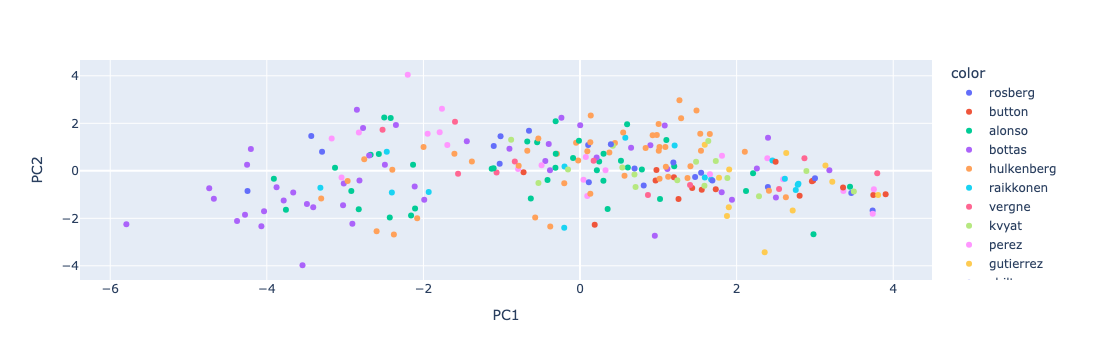

In [54]:
import plotly.express as px
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])

fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color=df['ref'],  #color by driver
    hover_data=[df['total_points'],df['logit_dnf'], df['logit_top10'], df['avg_finish'], df['ref'], df['year'],df['constructorRef']]
)
fig.show()

The scatter plot of drivers along PC1 and PC2 provides a visual summary of performance archetypes. Drivers located in the lower-left quadrant (negative PC1 and PC2), such as Max Verstappen and Lewis Hamilton, represent high-performing and consistent drivers. This is because their low DNF rates and high top-10 finish rates translate into negative PC1 values (since PC1 loads positively on DNF and negatively on top-10), while their stable results across seasons lead to negative PC2 values. In contrast, drivers in the lower-right quadrant, such as Nikita Mazepin or Kevin Magnussen (in weaker seasons), exhibit poor performance: they have high DNF rates, low top-10 rates, and inconsistent results, producing high PC1 and near-zero or slightly positive PC2 values. Intermediate regions contain drivers with mixed traits—for example, some may have moderate finishing consistency but occasional standout results, which positions them near the center of the plot. This pattern demonstrates that PC1 largely captures overall performance and reliability, while PC2 captures relative consistency and variance in results, making the scatter plot a useful precursor for clustering drivers into performance archetypes.

With the principal components extracted and interpreted, the dataset is now transformed into a concise, informative space that emphasizes the key dimensions of driver performance. This representation highlights natural differences between drivers, from high-performing and consistent individuals to those with more variable or lower results, without being obscured by redundant metrics. Moving forward, these principal components provide an ideal foundation for clustering, enabling the identification of distinct driver archetypes and patterns that can reveal underlying performance profiles across seasons.

In [53]:
pca_df.to_csv("pca_5components.csv", index=False)